# Spotify Recommendation System

## Recommender

### Load Dataset

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("spotify.csv")
df.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Feature Selection

In [81]:
columns_to_keep = [
    'track_id', 'track_name', 'artists',
    'danceability', 'energy', 'valence',
    'tempo', 'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'popularity',
    'track_genre'
]

df = df[columns_to_keep]
df.head()

,track_id,track_name,artists,danceability,energy,valence,tempo,acousticness,instrumentalness,liveness,speechiness,popularity,track_genre
0,1L6aWPr4XyMKOm6BlGe1uz,Silver Bells,Stevie Wonder,0.409,0.336,0.549,114.590,0.383000,0.000000,0.1500,0.0301,0,indie
1,5FUXLd5vcwtR36lGLtKsWb,Little Saint Nick - 1991 Remix,The Beach Boys,0.602,0.553,0.971,130.594,0.108000,0.000000,0.0512,0.0328,0,rock
2,0Z2NiMOKlPxBNjecKIn0It,Shallow,Mental Theo,0.434,0.776,0.127,149.923,0.344000,0.000076,0.3560,0.0350,20,happy
3,23h5dBCGwvQrKpRGJhh53p,Cosa de Gusanos,BBS Paranoicos,0.421,0.910,0.722,170.005,0.000009,0.008460,0.2580,0.0490,31,hardcore
4,1YHZDfqcj4o0scuWw39ehw,夜了,Grasshopper,0.700,0.515,0.664,98.171,0.257000,0.000000,0.2290,0.0236,20,cantopop


### Data Cleaning

In [82]:
df.isnull().sum()

track_id            0
track_name          0
artists             0
danceability        0
energy              0
valence             0
tempo               0
acousticness        0
instrumentalness    0
liveness            0
speechiness         0
popularity          0
track_genre         0
dtype: int64

In [83]:
df = df.dropna()

In [84]:
df.isnull().sum()

track_id            0
track_name          0
artists             0
danceability        0
energy              0
valence             0
tempo               0
acousticness        0
instrumentalness    0
liveness            0
speechiness         0
popularity          0
track_genre         0
dtype: int64

In [85]:
df = df.sample(n=5000, random_state=20).reset_index(drop=True)

### Feature Scaling (Normalization) and Cosine Similarity

In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

features = ['danceability', 'energy', 'valence', 'tempo',
            'acousticness', 'instrumentalness', 'liveness',
            'speechiness', 'popularity']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for lower-dimensional representation
pca = PCA(n_components=5, random_state=20)
X_reduced = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

similarity_matrix = cosine_similarity(X_reduced)
print(similarity_matrix.shape)

Explained variance ratio: [0.24196055 0.15601755 0.14102464 0.1149254  0.10131658]
Total explained variance: 0.7552447237520159
(5000, 5000)


### Recommendation System 

In [87]:
def normalize_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def genre_soft_score(target_genre, candidate_genre):
    target_genre = normalize_text(target_genre)
    candidate_genre = normalize_text(candidate_genre)

    if target_genre == candidate_genre:
        return 1.0
    return 0.2

def artist_soft_score(target_artist, candidate_artists):
    target_artist = normalize_text(target_artist)
    candidate_artists = normalize_text(candidate_artists)

    if target_artist and target_artist in candidate_artists:
        return 1.0
    return 0.3

In [88]:
def recommend_songs(track_name, artist, n=10):
    track_name = normalize_text(track_name)
    artist = normalize_text(artist)

    matches = df[
        (df["track_name"].str.lower().str.contains(track_name, na=False, regex=False)) &
        (df["artists"].str.lower().str.contains(artist, na=False))
    ]

    if matches.empty:
        return "This song has not been found. Check track name and artist."

    track_id = matches.index[0]
    target_genre = df.loc[track_id, "track_genre"]
    target_artists = df.loc[track_id, "artists"]

    similarity_scores = list(enumerate(similarity_matrix[track_id]))
    scored_songs = []

    for i, audio_score in similarity_scores:
        if i == track_id:
            continue

        if (normalize_text(df.loc[i, "track_name"]) == track_name and
            normalize_text(df.loc[i, "artists"]) == artist):
            continue

        candidate_genre = df.loc[i, "track_genre"]
        candidate_artists = df.loc[i, "artists"]

        genre_score = genre_soft_score(target_genre, candidate_genre)
        artists_score = artist_soft_score(artist, candidate_artists)

        final_score = (0.7 * audio_score + 0.2 * genre_score + 0.1 * artists_score)

        scored_songs.append((i, audio_score, genre_score, artists_score, final_score))

    scored_songs = sorted(scored_songs, key=lambda x: x[4], reverse=True)
    top_songs = scored_songs[:n]

    song_indices = [x[0] for x in top_songs]
    similarity_scores_only = [x[1] for x in top_songs]
    genre_scores_only = [x[2] for x in top_songs]
    artist_scores_only = [x[3] for x in top_songs]
    final_scores = [x[4] for x in top_songs]

    recommendations = df.loc[song_indices, ["track_name", "artists", "track_genre", "popularity"]].copy()

    recommendations["similarity_score"] = similarity_scores_only
    recommendations["genre_score"] = genre_scores_only
    recommendations["artist_score"] = artist_scores_only
    recommendations["final_score"] = final_scores

    recommendations = recommendations.drop_duplicates(subset=["track_name", "artists"])

    return recommendations

### Testing the Recommender System 

#### Random Test Example

In [90]:
random_song = df.sample(1).iloc[0]

track_name = random_song["track_name"]
artist = random_song["artists"]

print("Input song:")
print(track_name, "-", artist)

recommend_songs(track_name, artist)

Input song:
Transgender - Crystal Castles


,track_name,artists,track_genre,popularity,similarity_score,genre_score,artist_score,final_score
2117,Feel Good,Datsik;Zack The Lad,breakbeat,15,0.993445,0.2,0.3,0.765411
3204,Ransom Note,Confess,iranian,8,0.987163,0.2,0.3,0.761014
3400,Joined at the Ass,Cattle Decapitation,grindcore,11,0.982576,0.2,0.3,0.757804
1324,Memories,PERMEATE,iranian,0,0.979367,0.2,0.3,0.755557
615,The Pecan Tree - Live,Deafheaven,black-metal,18,0.978446,0.2,0.3,0.754912
353,Cameraman,Pig Destroyer,grindcore,12,0.978083,0.2,0.3,0.754658
3527,Way of the Rope,Naglfar,black-metal,16,0.975390,0.2,0.3,0.752773
3703,Ristiriita,Stam1na,heavy-metal,25,0.975092,0.2,0.3,0.752564
3860,Satan.Sex.Sin,Nathorg,iranian,0,0.973746,0.2,0.3,0.751623
3929,The Laws of Scourge,Sarcófago,black-metal,20,0.970865,0.2,0.3,0.749605


#### Manual tests

In [91]:
display(recommend_songs("Your Love Is King", "Sade"))  #comprehensive search
display(recommend_songs("Now Or Never", "Matt"))  #half artist name
display(recommend_songs("No Role Mod", "J. Cole"))  #half song name
display(recommend_songs("Fair", "Dra"))  #half both song name and artist name 
display(recommend_songs("Look At Me!", ""))  #missing artist name
display(recommend_songs("", "Drake"))  #missing song name 
display(recommend_songs("random_song", "unknown_artist"))  #non-existing song

,track_name,artists,track_genre,popularity,similarity_score,genre_score,artist_score,final_score
3980,Good Day Sunshine - Remastered 2009,The Beatles,british,58,0.941776,1.0,0.3,0.889243
3663,Stand by Me,Seal,british,60,0.890083,1.0,0.3,0.853058
680,Ruby Tuesday,The Rolling Stones,british,63,0.810582,1.0,0.3,0.797407
1781,All I Ask,Adele,british,74,0.797428,1.0,0.3,0.788200
1045,From The Morning,Nick Drake,british,58,0.778895,1.0,0.3,0.775226
3998,Ishq Wala Love,Vishal-Shekhar;Salim Merchant;Neeti Mohan;Shek...,pop,70,0.993828,0.2,0.3,0.765680
2599,"Aarariraro(From ""Raam"")",Yuvan Shankar Raja;K. J. Yesudas,k-pop,55,0.985453,0.2,0.3,0.759817
728,Nothing,Keenan Te,songwriter,48,0.983899,0.2,0.3,0.758729
1189,O Rangrez,Shankar-Ehsaan-Loy;Shreya Ghoshal;Javed Bashir...,pop-film,57,0.970722,0.2,0.3,0.749505
1583,"Kaalathukkum Nee Venum - From ""Vendhu Thanindh...",A.R. Rahman;Silambarasan TR;Rakshita Suresh,pop,65,0.966929,0.2,0.3,0.746850


,track_name,artists,track_genre,popularity,similarity_score,genre_score,artist_score,final_score
4275,IDWK,DVBBS;blackbear,progressive-house,52,0.984341,1.0,0.3,0.919039
3157,The Spook,KSHMR;Basskillers;B3nte,progressive-house,49,0.979549,1.0,0.3,0.915685
442,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris;Tinie Tempah,progressive-house,62,0.964625,1.0,0.3,0.905237
959,Time,Syn Cole,progressive-house,43,0.956521,1.0,0.3,0.899565
2496,Giant (with Rag'n'Bone Man),Calvin Harris;Rag'n'Bone Man,progressive-house,73,0.936180,1.0,0.3,0.885326
4852,Brass,Dirty Rush & Gregor Es,progressive-house,62,0.923546,1.0,0.3,0.876482
1574,Quechua,Quintino;Thomas Gold,progressive-house,60,0.918003,1.0,0.3,0.872602
3800,Ready To Love,KSHMR,progressive-house,62,0.910876,1.0,0.3,0.867613
1436,Burn Out (feat. Dewain Whitmore),Martin Garrix;Justin Mylo;Dewain Whitmore,progressive-house,58,0.904854,1.0,0.3,0.863398
921,Hero,Afrojack;David Guetta,progressive-house,64,0.896744,1.0,0.3,0.857721


,track_name,artists,track_genre,popularity,similarity_score,genre_score,artist_score,final_score
3600,Elevated,Shubh,hip-hop,76,0.953541,1.0,0.3,0.897479
3859,Gangsta's Paradise,Coolio;L.V.,hip-hop,89,0.947851,1.0,0.3,0.893496
3022,Thangamey,Anirudh Ravichander,hip-hop,58,0.924432,1.0,0.3,0.877103
4133,Ilzaam (From the Album 'Industry'),Arjun Kanungo;King,hip-hop,67,0.922488,1.0,0.3,0.875742
104,295,Sidhu Moose Wala,hip-hop,78,0.919515,1.0,0.3,0.873660
3276,Chances,AP Dhillon;Gurinder Gill;Money Musik,hip-hop,61,0.914173,1.0,0.3,0.869921
4378,Tera Mera Viah,Jass Manak,hip-hop,61,0.907519,1.0,0.3,0.865263
1608,Stan,Eminem;Dido,hip-hop,85,0.897436,1.0,0.3,0.858205
106,Few Days,Amantej Hundal;Karan Aujla,hip-hop,59,0.888593,1.0,0.3,0.852015
3073,Look At Me!,XXXTENTACION,hip-hop,82,0.879994,1.0,0.3,0.845996


,track_name,artists,track_genre,popularity,similarity_score,genre_score,artist_score,final_score
3073,Look At Me!,XXXTENTACION,hip-hop,82,0.873759,1.0,0.3,0.841632
1779,Aasman Ko Chukar,Daler Mehndi;Hrishikesh;Neuman;FRANCO;Shazneen...,hip-hop,64,0.767796,1.0,0.3,0.767457
3022,Thangamey,Anirudh Ravichander,hip-hop,58,0.763662,1.0,0.3,0.764564
104,295,Sidhu Moose Wala,hip-hop,78,0.761442,1.0,0.3,0.763010
3859,Gangsta's Paradise,Coolio;L.V.,hip-hop,89,0.755318,1.0,0.3,0.758723
2214,overwhelmed - Chri$tian Gate$ remix,Royal & the Serpent;Chri$tian Gate$,indie,69,0.952582,0.2,0.3,0.736808
1024,Outside (feat. Ellie Goulding),Calvin Harris;Ellie Goulding,house,79,0.948355,0.2,0.3,0.733849
3966,Amplifier,Imran Khan,hip-hop,70,0.714407,1.0,0.3,0.730085
2887,The Man Who Sold The World,Nirvana,alt-rock,76,0.941083,0.2,0.3,0.728758
1260,Difficult,Gracie Abrams,indie-pop,72,0.935813,0.2,0.3,0.725069


,track_name,artists,track_genre,popularity,similarity_score,genre_score,artist_score,final_score
3022,Thangamey,Anirudh Ravichander,hip-hop,58,0.964608,1.0,0.3,0.905225
104,295,Sidhu Moose Wala,hip-hop,78,0.945195,1.0,0.3,0.891637
3859,Gangsta's Paradise,Coolio;L.V.,hip-hop,89,0.904939,1.0,0.3,0.863457
1608,Stan,Eminem;Dido,hip-hop,85,0.886738,1.0,0.3,0.850717
3612,No Role Modelz,J. Cole,hip-hop,88,0.879994,1.0,0.3,0.845996
1700,Fair Trade (with Travis Scott),Drake;Travis Scott,hip-hop,83,0.873759,1.0,0.3,0.841632
3600,Elevated,Shubh,hip-hop,76,0.865917,1.0,0.3,0.836142
106,Few Days,Amantej Hundal;Karan Aujla,hip-hop,59,0.847083,1.0,0.3,0.822958
3276,Chances,AP Dhillon;Gurinder Gill;Money Musik,hip-hop,61,0.826397,1.0,0.3,0.808478
3857,"Bhaag D.K. Bose, Aandhi Aayi",Ram Sampath,hip-hop,58,0.818355,1.0,0.3,0.802849


,track_name,artists,track_genre,popularity,similarity_score,genre_score,artist_score,final_score
471,She Dances,Billie Marten,british,53,0.979054,1.0,0.3,0.915338
680,Ruby Tuesday,The Rolling Stones,british,63,0.952803,1.0,0.3,0.896962
1781,All I Ask,Adele,british,74,0.909549,1.0,0.3,0.866685
1251,Irene's Theme,David Arnold;Michael Price,british,36,0.891017,1.0,0.3,0.853712
3980,Good Day Sunshine - Remastered 2009,The Beatles,british,58,0.847527,1.0,0.3,0.823269
31,Guiding Light,Foy Vance;Ed Sheeran,british,48,0.839051,1.0,0.3,0.817335
1169,Never Tear Us Apart,Paloma Faith,british,53,0.786191,1.0,0.3,0.780333
795,Your Love Is King,Sade,british,65,0.778895,1.0,0.3,0.775226
591,blue,the bootleg boy;artemis orion,sad,53,0.995979,0.2,0.3,0.767185
2361,Chasing Cars - Acoustic,Bailey Rushlow,acoustic,51,0.992948,0.2,0.3,0.765063


'This song has not been found. Check track name and artist.'

## Recommendation Evaluation

In [92]:
def precision_at_k(recommended_genres, target_genre, k):
    recommended_genres_k = recommended_genres[:k]
    hits = 0
    for g in recommended_genres_k:
        if normalize_text(g) == normalize_text(target_genre):
            hits += 1
    return hits / k

def evaluate_recommender(sample_size=100, k=10):
    precisions = []

    sampled_rows = df.sample(sample_size, random_state=20)

    for idx, row in sampled_rows.iterrows():
        track_name = row["track_name"]
        artist = row["artists"]
        target_genre = row["track_genre"]

        recs = recommend_songs(track_name, artist, n=k)

        if isinstance(recs, str):
            continue

        rec_genres = recs["track_genre"].tolist()
        p_at_k = precision_at_k(rec_genres, target_genre, k)
        precisions.append(p_at_k)

    if len(precisions) == 0:
        return None

    return {
        "sample_size_used": len(precisions),
        "precision_at_k_mean": np.mean(precisions),
        "precision_at_k_std": np.std(precisions)
    }

evaluation_results = evaluate_recommender(sample_size=100, k=10)
evaluation_results

{'sample_size_used': 100,
 'precision_at_k_mean': 0.652,
 'precision_at_k_std': 0.35734577092782277}

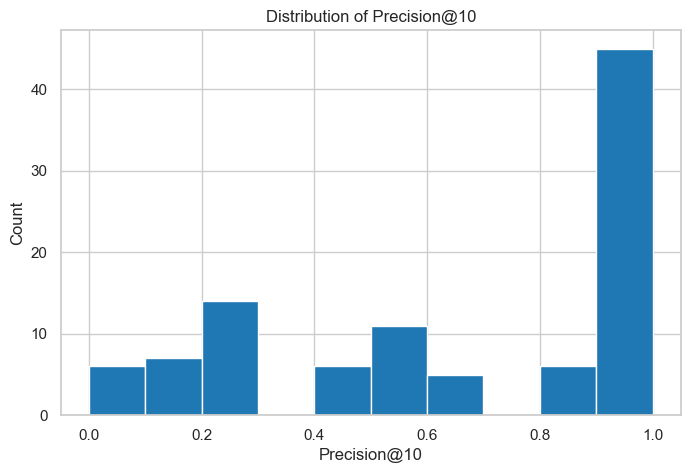

In [93]:
precision_values = []

sampled_rows = df.sample(100, random_state=20)

for idx, row in sampled_rows.iterrows():
    recs = recommend_songs(row["track_name"], row["artists"], n=10)
    if isinstance(recs, str):
        continue
    p = precision_at_k(recs["track_genre"].tolist(), row["track_genre"], 10)
    precision_values.append(p)

plt.figure(figsize=(8,5))
plt.hist(precision_values, bins=10)
plt.title("Distribution of Precision@10")
plt.xlabel("Precision@10")
plt.ylabel("Count")
plt.show()

## SQL Analytics

In [94]:
import sqlite3

conn = sqlite3.connect("spotify_project.db")
df.to_sql("songs", conn, if_exists="replace", index=False)

print("Table 'songs' created successfully in SQLite database")

Table 'songs' created successfully in SQLite database


In [96]:
query = "SELECT * FROM songs LIMIT 5;"
pd.read_sql(query, conn)

,track_id,track_name,artists,danceability,energy,valence,tempo,acousticness,instrumentalness,liveness,speechiness,popularity,track_genre
0,4HMsQy6myJNy1GoCLsIDDR,與海無關 (《比悲傷更悲傷的故事》影集版插曲),告五人,0.654,0.227,0.373,78.155,0.90600,0.000021,0.0910,0.0298,52,mandopop
1,2SAASgfsXQqRCq5hWEUGnp,These Days (I Barely Get By),George Jones,0.470,0.288,0.329,73.733,0.91300,0.000007,0.0590,0.0282,14,honky-tonk
2,2ij6KmSIiA46M3TpZavPNK,Home,Solomun,0.679,0.707,0.258,120.007,0.00634,0.855000,0.1800,0.0400,11,minimal-techno
3,0ncgj6yTGzZ4GwX2dbXAKE,Goodbye (feat. Xillions),le Shuuk;Xillions,0.689,0.801,0.514,142.062,0.03590,0.000547,0.0743,0.1220,54,techno
4,1Q2fYlSdwuutWj3QplhY9q,Riot,Three Days Grace,0.185,0.948,0.316,196.578,0.01040,0.000000,0.1050,0.1470,71,grunge


### Genre Popularity Analysis

In [97]:
# this query analyzes teh average popularity of each music genre, considering only genres with a sufficient number of tracks (at least 20).

query = """
SELECT track_genre,
    COUNT(*) AS total_tracks,
    ROUND(AVG(popularity), 2) AS avg_popularity
FROM songs
GROUP BY track_genre
HAVING COUNT(*) >= 20
ORDER BY avg_popularity DESC
LIMIT 10;
"""

top_genres_popularity = pd.read_sql(query, conn)
top_genres_popularity

,track_genre,total_tracks,avg_popularity
0,pop-film,31,58.55
1,k-pop,53,56.34
2,pop,45,55.53
3,sad,33,53.36
4,indian,42,51.24
5,metal,47,50.77
6,chill,29,50.14
7,sertanejo,49,47.94
8,anime,46,47.70
9,grunge,31,46.68


### Genre Energy Analysis

In [98]:
# this query analyzes the average energy level of each music genre

query = """
SELECT track_genre,
    ROUND(AVG(energy), 2) AS avg_energy
FROM songs
GROUP BY track_genre
ORDER BY avg_energy DESC
LIMIT 10;
"""

top_genres_energy = pd.read_sql(query, conn)
top_genres_energy

,track_genre,avg_energy
0,death-metal,0.94
1,metalcore,0.93
2,happy,0.91
3,hardstyle,0.90
4,grindcore,0.90
5,heavy-metal,0.89
6,breakbeat,0.89
7,black-metal,0.89
8,party,0.88
9,j-idol,0.87


### Highly Danceable and Popular Songs

In [99]:
# highly danceable and popular songs

query = """
SELECT track_name, artists, track_genre, danceability, popularity
FROM songs 
WHERE danceability >= 0.7 AND popularity >= 70
GROUP BY track_name, artists
ORDER BY track_name ASC
LIMIT 15;
"""

top_songs = pd.read_sql(query, conn)
top_songs

,track_name,artists,track_genre,danceability,popularity
0,7 rings,Ariana Grande,pop,0.778,84
1,Airplane pt.2,BTS,k-pop,0.770,72
2,Amplifier,Imran Khan,hip-hop,0.727,70
3,Andrea,Bad Bunny;Buscabulla,reggaeton,0.797,86
4,Angel,Shaggy;Rayvon,reggae,0.740,74
5,Baila Baila Baila - Remix,Ozuna;Daddy Yankee;J Balvin;Farruko;Anuel AA,reggaeton,0.785,76
6,Billie Bossa Nova,Billie Eilish,electro,0.895,76
7,Blank Space,Taylor Swift,pop,0.760,85
8,Butterfly,Crazy Town,alt-rock,0.736,73
9,CIRCUS (Korean Ver.),Stray Kids,k-pop,0.788,70


### Top Artists by Number of Unique Songs

In [100]:
# this analysis identifies the artists with the highest number of unique songs

query = """
SELECT artists, 
    COUNT(DISTINCT track_name) AS total_unique_tracks
FROM songs
GROUP BY artists
ORDER BY total_unique_tracks DESC
LIMIT 15;
"""

top_artists = pd.read_sql(query, conn)
top_artists

,artists,total_unique_tracks
0,Scooter,14
1,George Jones,14
2,The Beatles,11
3,The Prophet,10
4,Red Hot Chili Peppers,10
5,Linkin Park,10
6,Prateek Kuhad,8
7,Los Prisioneros,8
8,Germaine Franco,8
9,Feid,8


### Average Audio Profile by Genre

In [101]:
query = """ 
SELECT track_genre,
    ROUND(AVG(energy), 2) AS avg_energy,
    ROUND(AVG(danceability), 2) AS avg_danceability,
    ROUND(AVG(valence), 2) AS avg_valence,
    ROUND(AVG(acousticness), 2) AS avg_acousticness
FROM songs
GROUP BY track_genre
ORDER BY avg_energy DESC
LIMIT 15;
"""

genre_audio_profile = pd.read_sql(query, conn)
genre_audio_profile

,track_genre,avg_energy,avg_danceability,avg_valence,avg_acousticness
0,death-metal,0.94,0.40,0.24,0.03
1,metalcore,0.93,0.42,0.34,0.00
2,happy,0.91,0.51,0.31,0.06
3,hardstyle,0.90,0.53,0.25,0.04
4,grindcore,0.90,0.26,0.21,0.02
5,heavy-metal,0.89,0.41,0.38,0.02
6,breakbeat,0.89,0.59,0.45,0.01
7,black-metal,0.89,0.27,0.19,0.03
8,party,0.88,0.67,0.67,0.05
9,j-idol,0.87,0.52,0.50,0.16


### Genres Above Average Popularity

In [102]:
# this query identifies music genres whose average popularity is above the overall average popularity

query = """ 
SELECT track_genre, 
    ROUND(AVG(popularity), 2) AS avg_popularity
FROM songs
GROUP BY track_genre
HAVING avg_popularity >= (SELECT AVG(popularity)
                          FROM songs)
ORDER BY avg_popularity DESC
LIMIT 15;
"""

top_genres = pd.read_sql(query, conn)
top_genres

,track_genre,avg_popularity
0,pop-film,58.55
1,k-pop,56.34
2,pop,55.53
3,sad,53.36
4,indian,51.24
5,metal,50.77
6,chill,50.14
7,sertanejo,47.94
8,anime,47.70
9,grunge,46.68


## Exploratory Data Analysis (EDA)

In [103]:
# basic style
sns.set_style("whitegrid")
sns.set_context("notebook")

# default figure size
plt.rcParams["figure.figsize"] = (8, 5)

### Popularity Distribution

This plot shows how song popularity is distributed across the dataset.
It helps identify whether most songs have low, medium, or high popularity.

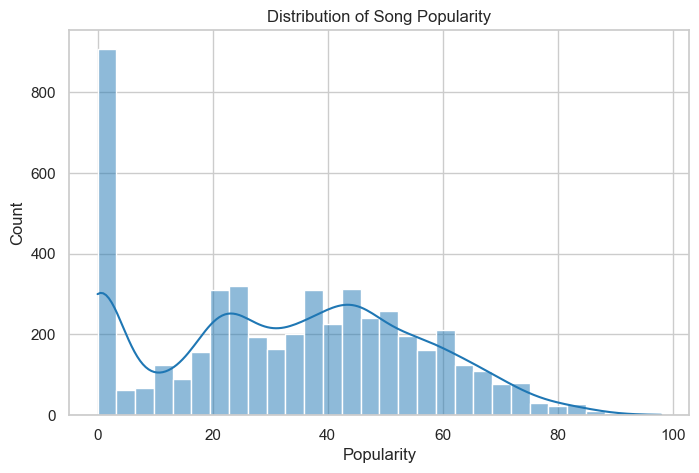

In [104]:
plt.figure()

sns.histplot(df["popularity"], bins=30, kde=True)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")

plt.show()

### Correlation Heatmap

This heatmap shows the relationships between the main numerical audio features in the dataset.
It helps identify which features are positively or negatively correlated.

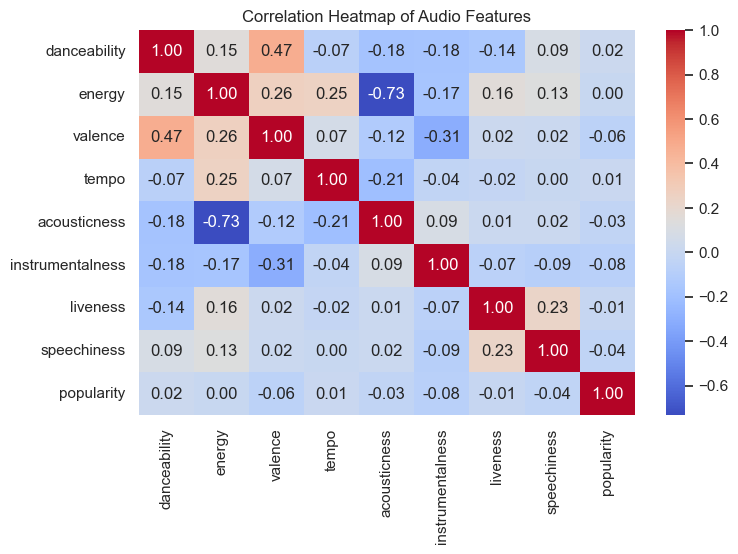

In [105]:
corr_matrix = df[features].corr()

plt.figure()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Audio Features")
plt.show()

### Danceability vs Energy

This scatter plot explores the relationship between danceability and energy in the sampled dataset.

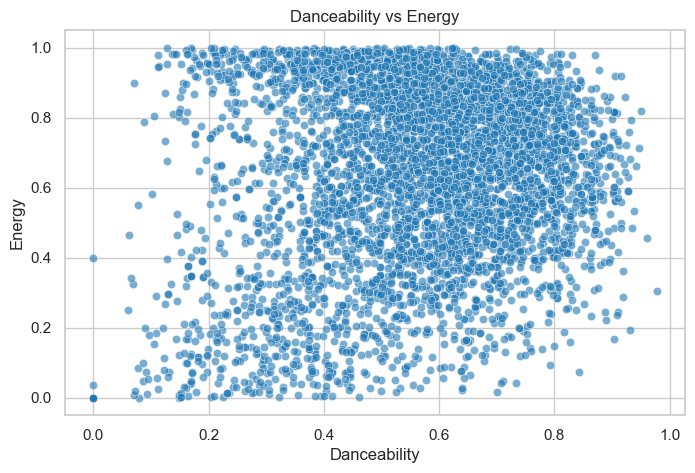

In [106]:
plt.figure()

sns.scatterplot(x=df["danceability"], y=df["energy"], alpha=0.6)

plt.title("Danceability vs Energy")
plt.xlabel("Danceability")
plt.ylabel("Energy")

plt.show()

### Recommendation Similarity Analysis

This analysis compares the audio features of an input song with the features of its recommended songs.
The goal is to visually examine whether the recommender returns musically similar tracks.

In [107]:
scaled_features_df = pd.DataFrame(X_scaled, columns=features, index=df.index)
scaled_features_df.head()

,danceability,energy,valence,tempo,acousticness,instrumentalness,liveness,speechiness,popularity
0,0.490063,-1.651027,-0.405747,-1.461330,1.799733,-0.493574,-0.641083,-0.499071,0.856359
1,-0.554197,-1.407704,-0.575037,-1.609451,1.820925,-0.493622,-0.806962,-0.513505,-0.844418
2,0.631946,0.263646,-0.848210,-0.059443,-0.923924,2.298320,-0.179731,-0.407057,-0.978690
3,0.688699,0.638602,0.136752,0.679319,-0.834433,-0.491857,-0.727651,0.332666,0.945874
4,-2.171664,1.224971,-0.625055,2.505404,-0.911632,-0.493644,-0.568511,0.558191,1.706748


In [56]:
random_song = df.sample(1).iloc[0]

track_name = random_song["track_name"]
artist = random_song["artists"]

print("Input song:")
print(track_name, "-", artist)

recs = recommend_songs(track_name, artist)
recs

Input song:
Uns Dias - Ao Vivo - Os Paralamas Do Sucesso


,track_name,artists,track_genre,popularity,similarity_score,genre_score,artist_score,final_score
3918,Lilás (Ao Vivo),Djavan,mpb,40,0.974693,1.0,0.3,0.912285
1142,O Portão,Luiza Possi,mpb,38,0.948545,1.0,0.3,0.893982
4436,Eu Nasci Há 10 Mil Anos Atrás,Raul Seixas,mpb,40,0.898640,1.0,0.3,0.859048
710,À Sua Maneira (De Música Ligera) (feat. Seu Jo...,Capital Inicial;Seu Jorge,mpb,49,0.862429,1.0,0.3,0.833700
3686,Inferno são os outros,Detonautas Roque Clube,mpb,48,0.849620,1.0,0.3,0.824734
4484,Bem Simples - Ao Vivo,Roupa Nova;Ed Motta,mpb,41,0.829078,1.0,0.3,0.810354
4866,Chão de Giz (Ao Vivo),Zé Ramalho,mpb,45,0.819985,1.0,0.3,0.803989
4081,O carimbador maluco,Raul Seixas,mpb,46,0.798048,1.0,0.3,0.788634
1230,Kryptônia,Zé Ramalho,mpb,44,0.784142,1.0,0.3,0.778900
4534,A Carta (Ao Vivo),Djavan,mpb,39,0.779846,1.0,0.3,0.775892


In [108]:
input_match = df[
    (df["track_name"].str.lower().str.contains(track_name.lower(), na=False)) &
    (df["artists"].str.lower().str.contains(artist.lower(), na=False))
]

input_id = input_match.index[0]
input_id

983

In [109]:
rec_ids = recs.index.tolist()
rec_ids

[2555, 2086, 1644, 4975, 4137, 1810, 138, 2985, 612, 3891]

In [110]:
comparison_df = pd.concat([
    scaled_features_df.loc[[input_id]],
    scaled_features_df.loc[rec_ids]
])

comparison_df.index = ["Input"] + [f"Rec {i}" for i in range(1, len(rec_ids) + 1)]
comparison_df

,danceability,energy,valence,tempo,acousticness,instrumentalness,liveness,speechiness,popularity
Input,-0.259080,1.089348,-1.700819,0.541716,-0.942621,2.268930,0.131292,-0.426001,-1.291991
Rec 1,0.756803,-0.179122,-1.175249,-0.194232,0.700776,2.383221,0.079455,-0.462987,1.259175
Rec 2,0.529790,-0.721613,-0.948246,-0.561921,-0.537442,1.710538,-0.676332,-0.331280,0.901117
Rec 3,0.631946,-0.713635,-0.678920,-0.059275,-0.809305,2.095861,-0.674258,-0.473812,1.080146
Rec 4,0.858959,-0.454357,-0.486544,1.197640,0.222443,2.425672,-0.568511,1.000220,0.990631
Rec 5,-0.088820,-0.889147,-0.694310,-1.667601,-0.778425,0.975811,-0.634344,-0.456672,0.990631
Rec 6,-0.190976,-0.948980,-0.967483,-1.404822,-0.892862,-0.266041,-0.008669,-0.458476,0.453544
Rec 7,0.910036,-0.386545,-0.859753,-0.695136,0.107400,1.387258,-0.184915,-0.315042,0.945874
Rec 8,0.626270,0.287579,-1.109841,0.208059,-0.939000,2.330974,-0.678924,-0.328574,1.214418
Rec 9,-0.293132,-0.027544,-1.486512,-1.500220,-0.852295,-0.493637,-0.691365,-0.462085,0.364029


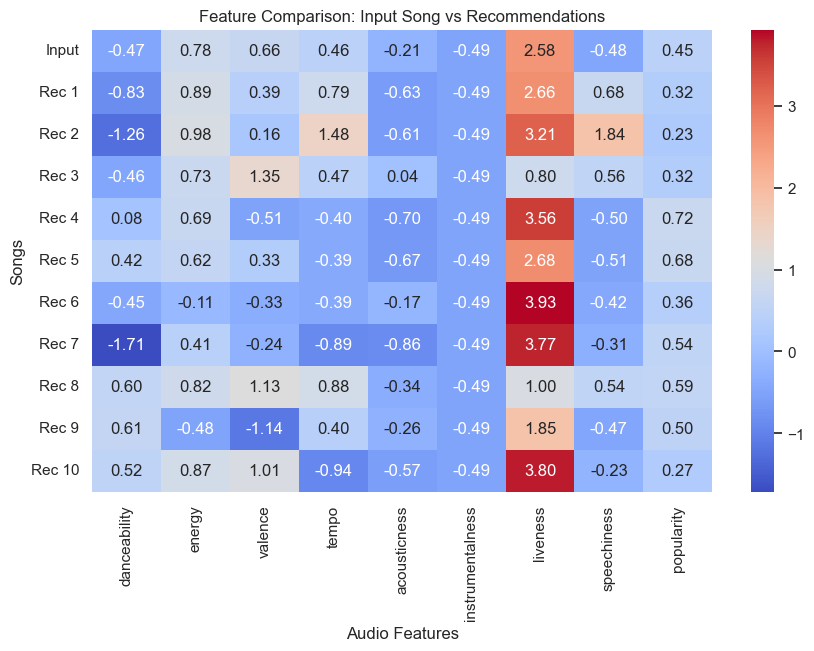

In [61]:
plt.figure(figsize=(10, 6))

sns.heatmap(comparison_df, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Comparison: Input Song vs Recommendations")
plt.xlabel("Audio Features")
plt.ylabel("Songs")

plt.show()

In [111]:
cluster_features = ['danceability', 'energy', 'valence', 'tempo',
                    'acousticness', 'instrumentalness', 'liveness',
                    'speechiness']

X_cluster = df[cluster_features]

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

## Unsupervised Learning

In [112]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [114]:
cluster_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=20, n_init=20)
    kmeans.fit(X_cluster_scaled)
    cluster_scores.append(kmeans.inertia_)

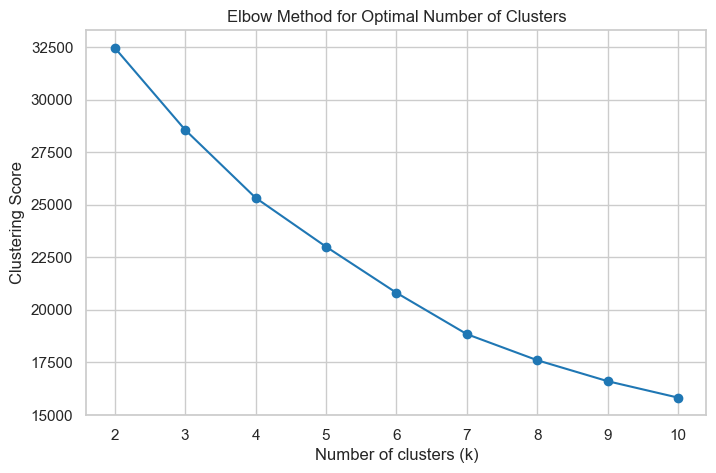

In [115]:
plt.figure()
plt.plot(range(2, 11), cluster_scores, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Clustering Score")
plt.show()

In [116]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=20, n_init=20)
    labels = kmeans.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)

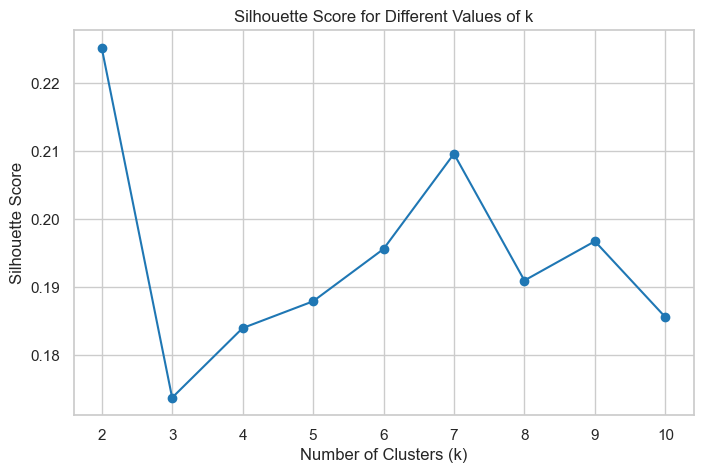

In [117]:
plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Score for Different Values of k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [118]:
kmeans = KMeans(n_clusters=2, random_state=20, n_init=20)
clusters = kmeans.fit_predict(X_cluster_scaled)

df["cluster"] = clusters

In [119]:
cluster_summary = df.groupby("cluster")[cluster_features].mean().round(3)
cluster_summary

,danceability,energy,valence,tempo,acousticness,instrumentalness,liveness,speechiness
cluster,,,,,,,,
0,0.477,0.331,0.339,109.650,0.725,0.238,0.184,0.053
1,0.602,0.758,0.531,126.355,0.156,0.118,0.226,0.097


In [120]:
cluster_sizes = df["cluster"].value_counts().sort_index()
cluster_sizes

cluster
0    1369
1    3631
Name: count, dtype: int64

<Figure size 1000x400 with 0 Axes>

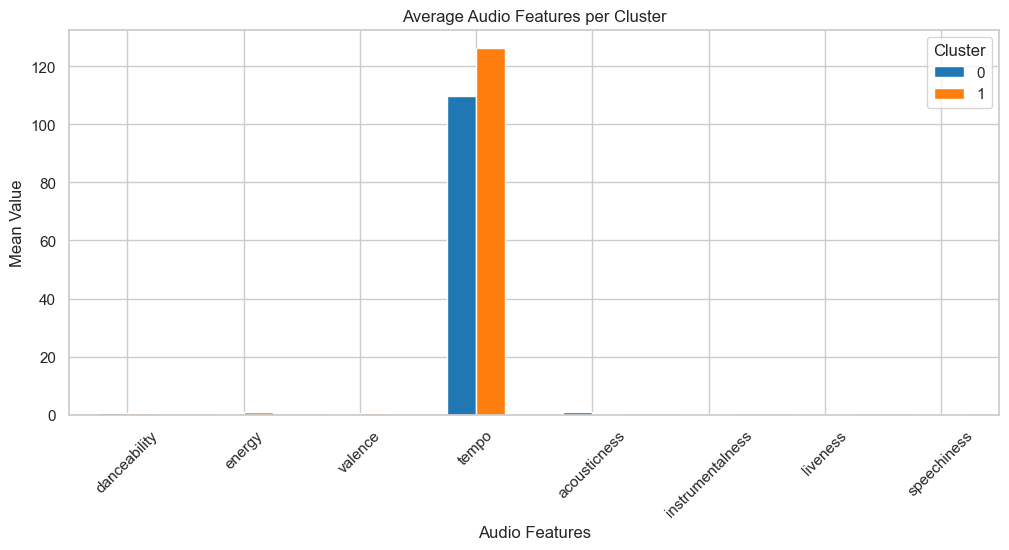

In [121]:
plt.figure(figsize=(10,4))
cluster_summary.T.plot(kind="bar", figsize=(12,5))
plt.title("Average Audio Features per Cluster")
plt.xlabel("Audio Features")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.show()

### PCA Visualization of Clusters

In [122]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

In [123]:
df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

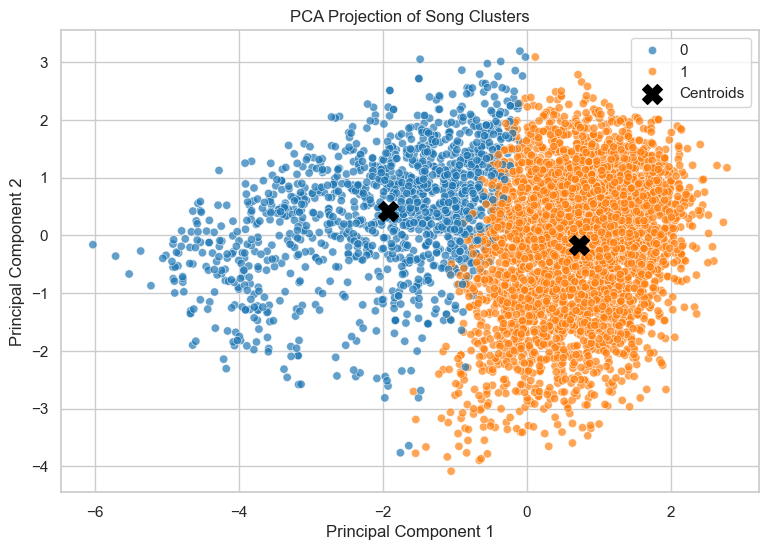

In [124]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster", alpha=0.7)

centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="black", s=200, marker="X", label="Centroids")

plt.title("PCA Projection of Song Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()
plt.show()

In [125]:
cluster_summary = df.groupby("cluster")[cluster_features].mean()
cluster_summary

,danceability,energy,valence,tempo,acousticness,instrumentalness,liveness,speechiness
cluster,,,,,,,,
0,0.477083,0.331498,0.339073,109.650330,0.724878,0.238483,0.184294,0.053120
1,0.601797,0.757561,0.531009,126.355472,0.155677,0.118253,0.226126,0.097189
